# Data (Observations)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
from matplotlib import dates as mdates

raw = xr.open_dataset('/mnt/p/XGBoost/F2EC838F4EF80D8EC62D8CB8AA68EA6E_netcdf.nc').fCO2_recommended\
.to_dataframe().set_index(['time']).sort_values(by='time',ascending=True)

In [2]:
df=raw
df = df[(df['longitude'] >= 30) & (df['longitude'] <= 120) & (df['latitude'] >= -30) & (df['latitude'] <= 30)]

In [3]:
df1 = df[~((df['longitude'] >= 110) & (df['longitude'] <= 120) & (df['latitude'] >= 0) & (df['latitude'] <= 30))]

In [6]:
df2=df1.to_xarray()
df2=df2.sel(time=slice('1980','2019'))

In [ ]:
sas=pd.read_excel('/mnt/p/XGBoost/NN_study/sas_allBoB_data/Surface_Inorg_data+chl_repeated_removed.xls').set_index('Month').sort_values(by='Month',ascending=True)
lon_sas=sas['Longitude'].values
lat_sas=sas['Latitude'].values
np.shape(lat_sas)

# Figure 1

# (a)

In [ ]:
from mpl_toolkits.basemap import Basemap
import matplotlib.patches as mpatches

plt.rcParams['font.weight']='bold'
fig,ax=plt.subplots(figsize=(12,10))
m = Basemap(projection='merc',llcrnrlat=-30.1,urcrnrlat=30.1,\
            llcrnrlon=30,urcrnrlon=120.1,resolution='c',ax=ax)
m.drawcoastlines()
m.fillcontinents(color='gray',lake_color='gray')
# draw parallels and meridians.
# m.drawparallels(np.arange(-90.,91.,30.))
# m.drawmeridians(np.arange(-180.,181.,60.))
m.drawparallels(range(-90, 100, 10), linewidth=0, labels=[1,0,0,1],color='white', zorder=0,fontsize=16,fontweight='bold')
m.drawmeridians(range(40, 120, 10),linewidth=0,labels=[1,0,0,1],color='white', zorder=0,fontsize=16,fontweight='bold')


x,y= m(df1.longitude,df1.latitude)

mpp=m.scatter(x,y,c=mdates.date2num(df1.index.to_numpy()),s=3.5,cmap='gist_rainbow_r')
cb=plt.colorbar(mpp,shrink=0.75,aspect=30,orientation='horizontal',pad=.05)
# loc = mdates.AutoDateLocator()


############################################################################
locator = mdates.AutoDateLocator()
cb.ax.yaxis.set_major_locator(locator)
cb.ax.yaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

# Adjust ticks to include start and end year
ticks = list(cb.ax.get_yticks())
start_tick = mdates.date2num(pd.Timestamp('1984-02-04 12:00:00'))
end_tick = mdates.date2num(pd.Timestamp('2019-12-30'))

# Ensure the first and last ticks are included
if start_tick not in ticks:
    ticks.insert(0, start_tick)
if end_tick not in ticks:
    ticks.append(end_tick)


cb.set_ticks(ticks)
cb.set_ticklabels([mdates.num2date(tick).strftime('%Y') for tick in ticks])





cb.set_label('Year', fontweight='bold',fontsize=16)



legend_patches = [
    mpatches.Patch(color='firebrick', alpha=0.3, label='Arabian Sea'),
    mpatches.Patch(color='olive',  alpha=0.3,label='Bay of Bengal'),
    mpatches.Patch(color='aquamarine',  alpha=0.5,label='Central IO'),
    mpatches.Patch(color='silver', label='Southern IO')
]



ax.legend(handles=legend_patches, loc='upper right', fontsize='medium',framealpha=1)



# lon1 = 73
# lat1 = -11
# x1,y1 = m(lon1,lat1)
# plt.text(x1,y1,'EIO',color='black',fontsize=20,fontweight='bold',alpha=1)

# lon1 = 73
# lat1 = -26
# x1,y1 = m(lon1,lat1)
# plt.text(x1,y1,'SIO',color='black',fontsize=20,fontweight='bold',alpha=1)

china_coords = [(106,-5),(120,-8.5),(120,29.5),(100,29.5),(99,10),(104,0),(106,-7),(120,-8)]
china_x,china_y = zip(*[m(lon,lat) for lon,lat in china_coords])

ax.fill(china_x,china_y,color='grey',zorder=3)

victo_coords = [(31,-20),(35,-20),(35,1),(31,1),(31,-20)]
victo_x,victo_y = zip(*[m(lon,lat) for lon,lat in victo_coords])
ax.fill(victo_x,victo_y,color='grey',zorder=3)

indi_coords = [(69.5,22),(92,23),(92,28),(69.5,28),(69.5,22)]
indi_x,indi_y = zip(*[m(lon,lat) for lon,lat in indi_coords])
ax.fill(indi_x,indi_y,color='grey',zorder=3)

indi_coords = [(65,26),(70,26),(70,29),(65,29),(65,26)]
indi_x,indi_y = zip(*[m(lon,lat) for lon,lat in indi_coords])
ax.fill(indi_x,indi_y,color='grey',zorder=3)


lon1 = 36
lat1 = 27
x1,y1 = m(lon1,lat1)
plt.text(x1,y1,'(a)',color='black',fontsize=20,fontweight='bold',alpha=1)


# lon1 = 85.5
# lat1 = 18
# x1,y1 = m(lon1,lat1)
# plt.text(x1,y1,'BoB',color='black',fontsize=20,fontweight='bold',alpha=1)


as_coords = [(30,0),(78,0),(78,30),(30,30),(30,0)]
as_x,as_y = zip(*[m(lon,lat) for lon,lat in as_coords])
ax.fill(as_x,as_y,color='firebrick',zorder=0,alpha=.3,label='AS')
# ax.legend(fontsize=40,loc='upper right',framealpha=0.75,ncol=1, prop = {'weight' : 'bold'})


bob_coords = [(78,0),(110,0),(110,30),(78,30),(78,0)]
bob_x,bob_y = zip(*[m(lon,lat) for lon,lat in bob_coords])
ax.fill(bob_x,bob_y,color='olive',zorder=0,alpha=.3)

cio_coords = [(30,-18),(120,-18),(120,0),(30,0),(30,-18)]
cio_x,cio_y = zip(*[m(lon,lat) for lon,lat in cio_coords])
ax.fill(cio_x,cio_y,color='aquamarine',zorder=0,alpha=.3)

sio_coords = [(30,-30),(120,-30),(120,-18),(30,-18),(30,-30)]
sio_x,sio_y = zip(*[m(lon,lat) for lon,lat in sio_coords])
ax.fill(sio_x,sio_y,color='silver',zorder=0,alpha=1)

# legend_patches = [
#     mpatches.Patch(color='firebrick', alpha=0.3, label='AS (Arabian Sea)'),
#     mpatches.Patch(color='olive',  alpha=0.3,label='BoB (Bay of Bengal)'),
#     mpatches.Patch(color='azure', label='CIO (Central Indian Ocean)'),
#     mpatches.Patch(color='silver', label='SIO (Southern Indian Ocean)')
# ]



# ax.legend(handles=legend_patches, loc='upper left', fontsize='medium',framealpha=.2)


# plt.savefig("/mnt/p/location_plot_IO_ROMS_V2.png", dpi=400,facecolor='w', edgecolor='w',orientation='potrait', bbox_inches='tight')


# (b)

In [ ]:
from mpl_toolkits.basemap import Basemap
import matplotlib.patches as mpatches

plt.rcParams['font.weight']='bold'
fig,ax=plt.subplots(figsize=(14,10))
m = Basemap(projection='merc',llcrnrlat=0,urcrnrlat=22.5,\
            llcrnrlon=77.5,urcrnrlon=100,resolution='c',ax=ax)
m.drawcoastlines()
m.fillcontinents(color='gray',lake_color='gray')

m.drawparallels(range(-90, 100, 5), linewidth=0, labels=[1,0,0,1],color='white', zorder=0,fontsize=16,fontweight='bold')
m.drawmeridians(range(40, 120, 5),linewidth=0,labels=[1,0,0,1],color='white', zorder=0,fontsize=16,fontweight='bold')


x,y= m(lon_sarma,lat_sarma)

mpp=m.scatter(x,y,c=mdates.date2num(sarma.index.to_numpy()),s=50.5,cmap='gist_rainbow_r',alpha=1)
cb=plt.colorbar(mpp,shrink=0.5,aspect=25,orientation='horizontal',pad=.04)
# loc = mdates.AutoDateLocator()


############################################################################
locator = mdates.AutoDateLocator()
cb.ax.yaxis.set_major_locator(locator)
cb.ax.yaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

# Adjust ticks to include start and end year
ticks = list(cb.ax.get_yticks())
start_tick = mdates.date2num(pd.Timestamp('1991-03-01'))
end_tick = mdates.date2num(pd.Timestamp('2019-06-01'))

del_tick = mdates.date2num(pd.Timestamp('1992'))


if start_tick not in ticks:
    ticks.insert(0, start_tick)
if end_tick not in ticks:
    ticks.append(end_tick)

tick_years = [mdates.num2date(tick).year for tick in ticks]


if 1992 in tick_years:
    index = tick_years.index(1992)
    del ticks[index]    
    

cb.set_ticks(ticks)
cb.set_ticklabels([mdates.num2date(tick).strftime('%Y') for tick in ticks])





cb.set_label('Year', fontweight='bold',fontsize=16)



# plt.savefig("/mnt/p/location_plot_IO_ROMS_SAS.png", dpi=400,facecolor='w', edgecolor='w',orientation='potrait', bbox_inches='tight')


# Figure 2 (Monthly Distribution)

/home/prasanna/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/home/prasanna/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/home/prasanna/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/home/prasanna/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: Matplotli

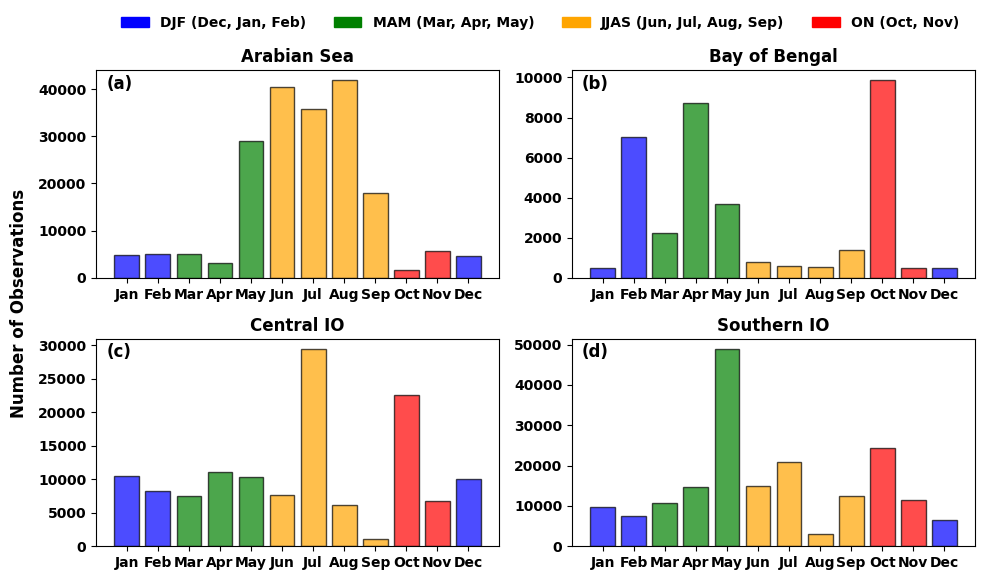

In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.weight'] = 'bold'

regions = ['Arabian Sea', 'Bay of Bengal', 'Central IO', 'Southern IO']
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
data = {
    'Arabian Sea': [ 4776,  5092,  5055,  3096, 28973, 40431, 35865, 41910, 17895,
        1702,  5648,  4609],
    'Bay of Bengal': [470, 7036, 2235, 8724, 3661, 792, 610, 550, 1375, 9864, 513,
                      482],
    'Central IO': [10464, 8194, 7491, 11052, 10312, 7665, 29451, 6176, 1129,                  
                   22565, 6698, 10061],
    'Southern IO': [9676, 7558, 10785, 14752, 48971, 14909, 20812, 2950, 12570,
                    24380, 11458, 6511]
}

# array([ 4776,  5092,  5055,  3096, 28973, 40431, 35865, 41910, 17895,
#         1702,  5648,  4609])

# Define seasonal colors
season_colors = {
    'DJF': 'blue',  # Dec, Jan, Feb
    'MAM': 'green', # Mar, Apr, May
    'JJA': 'orange',# Jun, Jul, Aug
    'SON': 'red'    # Sep, Oct, Nov
}

# Map each month to its season
month_to_season = {
    'Jan': 'DJF', 'Feb': 'DJF', 'Mar': 'MAM', 'Apr': 'MAM', 'May': 'MAM',
    'Jun': 'JJA', 'Jul': 'JJA', 'Aug': 'JJA', 'Sep': 'JJA', 'Oct': 'SON',
    'Nov': 'SON', 'Dec': 'DJF'
}

# Get colors for each month
month_colors = [season_colors[month_to_season[month]] for month in months]

fig, axs = plt.subplots(2, 2, figsize=(10, 6))
axs = axs.ravel()

for i, region in enumerate(regions):
    axs[i].bar(months, data[region], color=month_colors, alpha=0.7,edgecolor='k')
    axs[i].set_title(region, fontweight='bold')

fig.supylabel('Number of Observations', fontweight='bold')

# Add a legend for the seasons
legend_labels = ["DJF (Dec, Jan, Feb)", "MAM (Mar, Apr, May)", "JJAS (Jun, Jul, Aug, Sep)", "ON (Oct, Nov)"]
legend_colors = [season_colors[season] for season in ['DJF', 'MAM', 'JJA', 'SON']]
handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in legend_colors]
fig.legend(handles, legend_labels, loc='upper center',bbox_to_anchor=(0.3, 0.5, 0.5, 0.5), ncol=4, frameon=False, fontsize=10)#'small')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

for i in range(4):
    label = f"({chr(ord('a') +i)})"
    axs[i].text(0.025, 0.98, label, transform=axs[i].transAxes, fontsize=12, fontweight="bold", va="top") 


# plt.savefig('Data_distribution.png',dpi=400,bbox_inches='tight')

# Figure 4

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

plt.style.use('default')
plt.rcParams['font.weight']='bold'

In [ ]:
aras=pd.read_csv('scores_AS.csv')['score']
aras=aras.iloc[:151:15]

bob=pd.read_csv('scores_BoB.csv')['score']
bob=bob.iloc[:151:15]

cio=pd.read_csv('scores_CIO.csv')['score']
cio=cio.iloc[:151:15]

sio=pd.read_csv('scores_SIO.csv')['score']
sio=sio.iloc[:151:15]

In [ ]:
fig,ax=plt.subplots(2,2,figsize=(16,8))
ax=ax.ravel()
x_as = np.arange(0, 151, 15) 
y_as = aras

x_bob = np.arange(0,151, 15) 
y_bob = bob

x_cio = np.arange(0, 151, 15) 
y_cio = cio

x_sio = np.arange(0, 151, 15) 
y_sio = sio


ax[0].plot(x_as, y_as, '-*',linewidth=3,c='g')  
ax[0].scatter(x_as, y_as,marker='*',s=90,color='g')  
ax[0].set_xticks(np.arange(0, 151, 15))

ax[1].plot(x_bob, y_bob, '-*',linewidth=3,c='g')  
ax[1].scatter(x_bob, y_bob,marker='*',s=90,color='g')  
ax[1].set_xticks(np.arange(0, 151, 15))

ax[2].plot(x_cio, y_cio, '-*',linewidth=3,c='g')  
ax[2].scatter(x_cio, y_cio,marker='*',s=90,color='g')  
ax[2].set_xticks(np.arange(0, 151, 15))

ax[3].plot(x_sio, y_sio, '-*',linewidth=3,c='g')  
ax[3].scatter(x_sio, y_sio,marker='*',s=90,color='g')  
ax[3].set_xticks(np.arange(0, 151, 15))


for i in  range(4):
    ax[i].tick_params(axis='both', labelsize=12)  
    ax[i].yaxis.set_major_formatter(FormatStrFormatter('%.3f'))

ax[0].text(.35,.9,'Arabian Sea',transform=ax[0].transAxes,fontsize=14,fontweight='bold')
ax[1].text(.35,.9,'Bay of Bengal',transform=ax[1].transAxes,fontsize=14,fontweight='bold')
ax[2].text(.4,.9,'Central IO',transform=ax[2].transAxes,fontsize=14,fontweight='bold')
ax[3].text(.4,.9,'Southern IO',transform=ax[3].transAxes,fontsize=14,fontweight='bold')

ax[0].set_ylabel('RMSE (µatm)', fontsize=14, fontweight='bold')
ax[2].set_ylabel('RMSE (µatm)', fontsize=14, fontweight='bold')


ax[2].set_xlabel('Ensemble size', fontsize=14, fontweight='bold')
ax[3].set_xlabel('Ensemble size', fontsize=14, fontweight='bold')

ax[0].axvline(x=140,linestyle='--',c='b',linewidth=2)
ax[0].annotate(
    '140',  # The text to display
    xy=(140, 2.550),  # Point where the arrow points
    xytext=(110, 2.550),  # Position of the text
    arrowprops=dict(arrowstyle='->', color='b', lw=1.5),  # Arrow style
    fontsize=14, color='b', fontweight='bold'
)




ax[1].axvline(x=130,linestyle='--',c='b',linewidth=2)
ax[1].annotate(
    '130',  # The text to display
    xy=(130, 1.820),  # Point where the arrow points
    xytext=(100, 1.820),  # Position of the text
    arrowprops=dict(arrowstyle='->', color='b', lw=1.5),  # Arrow style
    fontsize=14, color='b', fontweight='bold'
)




ax[2].axvline(x=140,linestyle='--',c='b',linewidth=2)
ax[2].annotate(
    '140',  # The text to display
    xy=(140, 4.870),  # Point where the arrow points
    xytext=(110, 4.870),  # Position of the text
    arrowprops=dict(arrowstyle='->', color='b', lw=1.5),  # Arrow style
    fontsize=14, color='b', fontweight='bold'
)


ax[3].axvline(x=130,linestyle='--',c='b',linewidth=2)
ax[3].annotate(
    '130',  # The text to display
    xy=(130, 5.590),  # Point where the arrow points
    xytext=(100, 5.590),  # Position of the text
    arrowprops=dict(arrowstyle='->', color='b', lw=1.5),  # Arrow style
    fontsize=14, color='b', fontweight='bold'
)



ax[0].text(.075, .1, '(a)', transform=ax[0].transAxes, fontsize=14, fontweight='bold', va='top', ha='right')
ax[1].text(.075, .1, '(b)', transform=ax[1].transAxes, fontsize=14, fontweight='bold', va='top', ha='right')
ax[2].text(.075, .1, '(c)', transform=ax[2].transAxes, fontsize=14, fontweight='bold', va='top', ha='right')
ax[3].text(.075, .1, '(d)', transform=ax[3].transAxes, fontsize=14, fontweight='bold', va='top', ha='right')


# plt.savefig('Ensemble_size.png',dpi=500,bbox_inches='tight',facecolor='w', edgecolor='w')

# Figure 5

In [ ]:
ars = xr.open_dataset('misfit_AS.nc').pCO2_misfit
ars_as=ars.mean(dim=['LAT_RHO','LON_RHO'])  

ars_uncer= xr.open_dataset('Misfit_uncertainty_AS_models.nc').pCO2_misfit
ars_uncer=  ars_uncer.mean(dim=['LAT_RHO','LON_RHO'])

In [ ]:
bob = xr.open_dataset('misfit_BoB.nc').pCO2_misfit
bob=bob.mean(dim=['LAT_RHO','LON_RHO'])

bob_uncer= xr.open_dataset('Misfit_uncertainty_BoB_models.nc').pCO2_misfit
bob_uncer=  bob_uncer.mean(dim=['LAT_RHO','LON_RHO'])

In [ ]:
cio = xr.open_dataset('misfit_CIO.nc').pCO2_misfit
cio=cio.mean(dim=['LAT_RHO','LON_RHO']) 

cio_uncer= xr.open_dataset('Misfit_uncertainty_CIO_models.nc').pCO2_misfit
cio_uncer=  cio_uncer.mean(dim=['LAT_RHO','LON_RHO'])

In [ ]:
sio = xr.open_dataset('misfit_SIO.nc').pCO2_misfit
sio=sio.mean(dim=['LAT_RHO','LON_RHO'])

sio_uncer= xr.open_dataset('Misfit_uncertainty_SIO_models.nc').pCO2_misfit
sio_uncer=  sio_uncer.mean(dim=['LAT_RHO','LON_RHO'])      

In [ ]:
as_year=ars_as.groupby('TIME.year').mean()
as_uncer_year=ars_uncer.groupby('TIME.year').mean()

bob_year=bob.groupby('TIME.year').mean()
bob_uncer_year=bob_uncer.groupby('TIME.year').mean()

cio_year=cio.groupby('TIME.year').mean()
cio_uncer_year=cio_uncer.groupby('TIME.year').mean()

sio_year=sio.groupby('TIME.year').mean()
sio_uncer_year=sio_uncer.groupby('TIME.year').mean()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


fig, ax = plt.subplots(figsize=(14, 4))
ax.margins(x=0.01)
# Arabian Sea
ax.errorbar(as_year.year, as_year, yerr=as_uncer_year, fmt='o-', c='k', label='Arabian Sea', capsize=5,elinewidth=2)

# Bay of Bengal
ax.errorbar(bob_year.year, bob_year, yerr=bob_uncer_year, fmt='s-', c='b', label='Bay of Bengal', capsize=5,elinewidth=2)

# Central Indian Ocean
ax.errorbar(cio_year.year, cio_year, yerr=cio_uncer_year, fmt='^-', c='r', label='Central IO', capsize=5,elinewidth=2)

# Southern Indian Ocean
ax.errorbar(sio_year.year, sio_year, yerr=sio_uncer_year, fmt='d-', c='g', label='Southern IO', capsize=5,elinewidth=2)

# Set x-axis ticks and labels with minor and major ticks
major_ticks = list(range(1980, 2020, 4))
if 2019 not in major_ticks:  
    major_ticks.append(2019)
    
ax.set_xticks(major_ticks)  
ax.set_xticklabels(major_ticks, rotation=0, fontsize=12) 

ax.tick_params(axis='both', which='major', width=2, colors='black', length=6)  # Minor ticks
ax.tick_params(axis='both', which='minor', width=2, colors='black', length=4)  # Minor ticks


ax.set_xticks(range(1980, 2020), minor=True)


ax.set_xlim(1980, 2019)


ax.set_yticks([-25,-20,-15,-10,-5,0,5,10])  # Major ticks every 4 years and include 2019
ax.set_yticklabels([-25,-20,-15,-10,-5,0,5,10], rotation=0, fontsize=12)  # Major tick labels


ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel(r'$p$CO$_2$ deviant (µatm)', fontsize=14, fontweight='bold')
ax.legend(fontsize=14, loc='upper center',ncol=4,framealpha=0)


plt.tight_layout()


# plt.savefig("Missfit_with_uncertainty.png", dpi=400,facecolor='w', edgecolor='w',orientation='potrait', bbox_inches='tight')


# Figure 6

In [ ]:
boboa=pd.read_csv('Comparison_interann.csv')['pCO2'].to_numpy()
boboa_std=pd.read_csv('Comparison_interann.csv')['STD_pCO2'].to_numpy()
idx=np.isnan(rama)  #T/F binary to find nan

In [ ]:
pco2_roms=xr.open_dataset('post_process_RECCAP_pCO2_monthly_IO.nc').PCO21.sel(LON_RHO=slice(78,120),LAT_RHO=slice(0,30)).sel(TIME=slice('1980','2020'))
roms=pco2.interp(LON_RHO=90,LAT_RHO=15,method='nearest').sel(TIME=slice('1-2014','12-2018'))

In [ ]:
interannual_corrected =  xr.open_dataset('Corrected_ROMS_IO_new_updated1.nc').__xarray_dataarray_variable__
interannual_corrected_rama=interannual_corrected .interp(LON_RHO=90,LAT_RHO=15,method='nearest').sel(TIME=slice('1-2014','12-2018'))

In [ ]:
climatology_corrected_rama=xr.open_dataset('Corrected_ROMS_IO_climatology_misfit_final.nc').__xarray_dataarray_variable__.interp(LON_RHO=90,LAT_RHO=15,method='nearest').sel(TIME=slice('1-2014','12-2018'))

In [ ]:
roms[idx]=np.nan
interannual_corrected_rama[idx]=np.nan
climatology_corrected_rama[idx]=np.nan

In [ ]:
from matplotlib.dates import MonthLocator, DateFormatter
import datetime as dt
import xesmf as xe
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, FuncFormatter
from matplotlib.dates import YearLocator
month_fmt = DateFormatter('%b')
def m_fmt(x, pos=None):
    return month_fmt(x)[0]

In [ ]:
plt.rcParams['font.weight']='bold'
import matplotlib.dates as mdates
fig,ax=plt.subplots(figsize=(14,3))
ax.margins(x=0)

dat=pd.to_datetime(roms.TIME)-pd.Timedelta('15D')

plt.plot(dat,roms,linewidth=1.5,marker='*',markersize=6,c='g')
plt.plot(dat,climatology_corrected_rama,linewidth=1.5,marker='v',c='blue',markersize=4)
plt.plot(dat,interannual_corrected_rama,c='r',linewidth=1.5,linestyle='solid',marker='o',markersize=4)
plt.plot(dat,boboa,c='k',linewidth=1.5)
plt.fill_between(dat,boboa-boboa_std,boboa+boboa_std,alpha=0.25,color='k')
plt.ylabel(r'$\it{p}$CO$_2$ ($\mu$atm)',fontsize=12,fontweight='bold')
plt.ylim([340,460])


ax.xaxis.set_major_locator(MonthLocator(bymonth=6))
ax.tick_params(axis='x',which='major', length=0,width=2,pad=11)
ax.xaxis.set_minor_locator(MonthLocator(bymonthday=15,interval=1))
ax.tick_params(axis='x',which='minor',length=5, width=2,labelsize=13)
ax.xaxis.set_major_formatter(DateFormatter("\n%Y"))
ax.xaxis.set_minor_formatter(FuncFormatter(m_fmt))
ax.xaxis.set_tick_params(labelsize=16)


plt.legend(['IBR_Original','pCIBR_Clim','pCIBR_Int','BOBOA'],ncol=4,loc='upper left',framealpha=0,fontsize=12)
# plt.savefig('ROMS_corrected_RAMA_location.png',dpi=500,bbox_inches='tight')

# Figures 7-9

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.metrics import mean_squared_error as ms
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import r2_score
from skill_metrics import nash_sutcliffe_eff as nse
import xskillscore as xs

# SOCAT

In [ ]:
socat_pco= xr.open_dataset('/home/kunal/Apurva/Prasanna/SOCATv2022_tracks_gridded_monthly.nc').fco2_ave_unwtd.sel(xlon=slice(30,120),ylat=slice(-30,30)).sel(tmnth=slice('1980','2019'))

nonnan=socat_pco.where(socat_pco.notnull(),drop=False)
socat_pco_socatgrid=socat_pco.sel(tmnth=nonnan.tmnth,method='nearest')

my_data=xr.open_dataset('Corrected_ROMS_IO_new_updated1.nc').__xarray_dataarray_variable__
my_data

data_clim=xr.open_dataset('Corrected_ROMS_IO_climatology_misfit_final.nc').__xarray_dataarray_variable__

roms=xr.open_dataset('post_process_RECCAP_pCO2_monthly_IO.nc').PCO21

my_data=my_data.sel(LON_RHO=socat_pco.xlon,LAT_RHO=socat_pco.ylat,TIME=socat_pco.tmnth,method='nearest')
data_clim=data_clim.sel(LON_RHO=socat_pco.xlon,LAT_RHO=socat_pco.ylat,TIME=socat_pco.tmnth,method='nearest')

roms=roms.sel(LON_RHO=socat_pco.xlon,LAT_RHO=socat_pco.ylat,TIME=socat_pco.tmnth,method='nearest')
data=my_data

In [ ]:
def Taylor_skill(ref,mod):
    mask = ~np.isnan(ref) & ~np.isnan(mod)
    mod = mod[mask]
    ref = ref[mask]
    if len(ref) <= 2 or len(mod) <= 2:
        return np.nan
    STD=np.nanstd(mod)/np.nanstd(ref)
    TSS=(2*(1+np.corrcoef(ref,mod)[0][1])/(STD+1/STD)**2)
    return TSS

In [ ]:
aa=xs.rmse(socat_pco_socatgrid,data,dim='tmnth',skipna=True)
aa1=xs.rmse(socat_pco_socatgrid,data_clim,dim='tmnth',skipna=True)
bb=xs.rmse(socat_pco_socatgrid,roms,dim='tmnth',skipna=True)


aa_mae=xs.rmse(socat_pco_socatgrid,data,dim='tmnth',skipna=True)
aa1_mae=xs.mae(socat_pco_socatgrid,data_clim,dim='tmnth',skipna=True)
bb_mae=xs.mae(socat_pco_socatgrid,roms,dim='tmnth',skipna=True)


aa_taylor = xr.apply_ufunc(
    Taylor_skill,socat_pco_socatgrid,
    data,
    input_core_dims=[["tmnth"], ["tmnth"]],
    vectorize=True,
)

aa1_taylor  = xr.apply_ufunc(
    Taylor_skill,socat_pco_socatgrid,
    data_clim,
    input_core_dims=[["tmnth"], ["tmnth"]],
    vectorize=True,
)


bb_taylor  = xr.apply_ufunc(
    Taylor_skill,socat_pco_socatgrid,
    roms,
    input_core_dims=[["tmnth"], ["tmnth"]],
    vectorize=True,
)

In [ ]:
import cmocean as cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
fig,ax=plt.subplots(3,2,figsize=(16,10),sharey=True)
plt.rcParams['font.weight']='bold'
# plt.subplots_adjust(wspace=0.2)
ax=ax.ravel()


from mpl_toolkits.basemap import Basemap
map = Basemap(projection='merc', llcrnrlat=-30.001, urcrnrlat=30.01,
            llcrnrlon=30, urcrnrlon=120.01, resolution='c')

plt.subplots_adjust(wspace=-0.45,hspace=0.15)

lon1, lat1 = np.meshgrid(aa.xlon, aa.ylat)
lon2, lat2 = map(lon1,lat1)

for i in range(6):      

    initial=map.pcolormesh(lon2,lat2,(aa-bb),cmap=cm.cm.balance,ax=ax[0],vmin=-30,vmax=30)
    map.pcolormesh(lon2,lat2,(aa1-bb),cmap=cm.cm.balance,ax=ax[1],vmin=-30,vmax=30)


    r1=map.pcolormesh(lon2,lat2,(aa_mae-bb_mae),cmap=cm.cm.balance,ax=ax[2],vmin=-20,vmax=20)
    map.pcolormesh(lon2,lat2,(aa1_mae-bb_mae),cmap=cm.cm.balance,ax=ax[3],vmin=-20,vmax=20)

    r2=map.pcolormesh(lon2,lat2,(aa_taylor-bb_taylor),cmap=cm.cm.balance,ax=ax[4],vmin=-.3,vmax=.3)
    map.pcolormesh(lon2,lat2,(aa1_taylor-bb_taylor),cmap=cm.cm.balance,ax=ax[5],vmin=-.3,vmax=.3)
    


    map.drawcoastlines(linewidth=.75, ax=ax[i])
    map.fillcontinents(color='grey',lake_color='aqua', ax=ax[i])
    ax[i].tick_params(axis='both', labelsize=8)

    if i in [4,5]:
        map.drawmeridians(np.arange(40, 120.1, 20), labels=[0,0,0,1], color='white', fontsize=10, ax=ax[i],zorder=0)
    if i in [0,2,4]:
        map.drawparallels(np.arange(-30, 31, 10), labels=[1,0,0,0], color='white', fontsize=10, ax=ax[i],zorder=0)



ax[0].set_ylabel('$\Delta$ RMSE ($\mu$atm)',fontsize=12,fontweight='bold',labelpad=30)
ax[2].set_ylabel('$\Delta$ MAE ($\mu$atm)',fontsize=12,fontweight='bold',labelpad=30)
ax[4].set_ylabel('$\Delta$ TSS',fontsize=12,fontweight='bold',labelpad=30)



ax[0].set_title('pCIBR_Int - IBR_Original',fontsize=12,fontweight='bold')
ax[1].set_title('pCIBR_Clim - IBR_Original',fontsize=12,fontweight='bold')




cb=plt.colorbar(initial,ax=[ax[0],ax[1]],orientation='vertical',ticks=np.arange(-30,30.01,10),shrink=1,pad=0.02,aspect=20,extend='both')
cb1=plt.colorbar(r1,ax=[ax[2],ax[3]],orientation='vertical',ticks=np.arange(-20,20.01,10),shrink=1,pad=0.02,aspect=20,extend='both')
cb_c1=plt.colorbar(r2,ax=[ax[4],ax[5]],orientation='vertical',ticks=np.arange(-.3,.31,.1),shrink=1,pad=0.02,aspect=20,extend='both')

for cbar in [cb,cb1,cb_c1]:
    cbar.ax.tick_params(labelsize=12)





china_coords = [(106,-5),(120,-8.5),(120,29.5),(100,29.5),(99,10),(104,0),(106,-7),(120,-8)]
china_x,china_y = zip(*[map(lon,lat) for lon,lat in china_coords])
for i in range(6):
    ax[i].fill(china_x,china_y,color='grey',zorder=5)

victo_coords = [(31,-20),(35,-20),(35,1),(31,1),(31,-20)]
victo_x,victo_y = zip(*[map(lon,lat) for lon,lat in victo_coords])
for i in range(6):
    ax[i].fill(victo_x,victo_y,color='grey',zorder=5)

indi_coords = [(69.5,22),(92,23),(92,28),(69.5,28),(69.5,22)]
indi_x,indi_y = zip(*[map(lon,lat) for lon,lat in indi_coords])
for i in range(6):
    ax[i].fill(indi_x,indi_y,color='grey',zorder=5)

indi_coords = [(65,26),(70,26),(70,29),(65,29),(65,26)]
indi_x,indi_y = zip(*[map(lon,lat) for lon,lat in indi_coords])
for i in range(6):
    ax[i].fill(indi_x,indi_y,color='grey',zorder=5)

for i in range(6):
    label = f"({chr(ord('a') +i)})"
    ax[i].text(0.1, 0.98, label, transform=ax[i].transAxes, fontsize=12, fontweight="bold", va="top") 


# plt.savefig('Validation_SOCAT_IO1.png',dpi=400,bbox_inches='tight')

# CMEMS-LSCE-FFNN

In [ ]:
chau=xr.open_dataset('CMEMS-LSCE_r025_IndianOcean_1985to2021.nc').spco2.sel(time=slice('1985','2019'))
corrected=xr.open_dataset('Corrected_ROMS_IO_new_updated1.nc').__xarray_dataarray_variable__.sel(LON_RHO=chau.longitude,LAT_RHO=chau.latitude,method='nearest').sel(TIME=slice('1985','2019'))
roms=xr.open_dataset('post_process_RECCAP_pCO2_monthly_IO.nc').PCO21.sel(LON_RHO=chau.longitude,LAT_RHO=chau.latitude,method='nearest').sel(TIME=slice('1985','2019'))

corrected_clim=xr.open_dataset('Corrected_ROMS_IO_climatology_misfit_final.nc').__xarray_dataarray_variable__.sel(LON_RHO=chau.longitude,LAT_RHO=chau.latitude,method='nearest').sel(TIME=slice('1985','2019'))

chau=chau.rename({'time':'TIME'})
corrected['TIME']=np.array(chau.TIME)
corrected_clim['TIME']=np.array(chau.TIME)
roms['TIME']=np.array(chau.TIME)



In [ ]:
aa=xs.rmse(chau,corrected,dim='TIME',skipna=True)
aa1=xs.rmse(chau,corrected_clim,dim='TIME',skipna=True)
bb=xs.rmse(chau,roms,dim='TIME',skipna=True)


aa_mae=xs.rmse(chau,corrected,dim='TIME',skipna=True)
aa1_mae=xs.mae(chau,corrected_clim,dim='TIME',skipna=True)
bb_mae=xs.mae(chau,roms,dim='TIME',skipna=True)


aa_taylor = xr.apply_ufunc(
    Taylor_skill,chau,
    corrected,
    input_core_dims=[["TIME"], ["TIME"]],
    vectorize=True,
)

aa1_taylor  = xr.apply_ufunc(
    Taylor_skill,chau,
    corrected_clim,
    input_core_dims=[["TIME"], ["TIME"]],
    vectorize=True,
)


bb_taylor  = xr.apply_ufunc(
    Taylor_skill,chau,
    roms,
    input_core_dims=[["TIME"], ["TIME"]],
    vectorize=True,
)

((bb-aa)/bb).mean(),((bb-aa1)/bb).mean()
((bb_mae-aa_mae)*100/bb_mae).mean(),((bb_mae-aa1_mae)*100/bb_mae).mean()
((bb_taylor-aa_taylor)*100/bb_taylor).mean(),((bb_taylor-aa1_taylor)*100/bb_taylor).mean()

print('CHAU MAE')
((bb_mae.mean()-aa_mae.mean())*100)/bb_mae.mean(),((bb_mae.mean()-aa1_mae.mean())*100)/bb_mae.mean()


print('CHAU TSS')
((bb_taylor.mean()-aa_taylor.mean())*100)/bb_taylor.mean(),((bb_taylor.mean()-aa1_taylor.mean())*100)/bb_taylor.mean()





In [ ]:

import cmocean as cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
fig,ax=plt.subplots(3,2,figsize=(16,10),sharey=True)
plt.rcParams['font.weight']='bold'
# plt.subplots_adjust(wspace=0.2)
ax=ax.ravel()

# for i in [3,6]:
#     fig.delaxes(ax[i])
    

from mpl_toolkits.basemap import Basemap
map = Basemap(projection='merc', llcrnrlat=-30.001, urcrnrlat=30.01,
            llcrnrlon=30, urcrnrlon=120.01, resolution='c')

plt.subplots_adjust(wspace=-0.45,hspace=0.15)

lon1, lat1 = np.meshgrid(aa.longitude, aa.latitude)
lon2, lat2 = map(lon1,lat1)

for i in range(6):      

    initial=map.pcolormesh(lon2,lat2,(aa-bb),cmap=cm.cm.balance,ax=ax[0],vmin=-30,vmax=30)
    map.pcolormesh(lon2,lat2,(aa1-bb),cmap=cm.cm.balance,ax=ax[1],vmin=-30,vmax=30)


    r1=map.pcolormesh(lon2,lat2,(aa_mae-bb_mae),cmap=cm.cm.balance,ax=ax[2],vmin=-20,vmax=20)
    map.pcolormesh(lon2,lat2,(aa1_mae-bb_mae),cmap=cm.cm.balance,ax=ax[3],vmin=-20,vmax=20)

    r2=map.pcolormesh(lon2,lat2,(aa_taylor-bb_taylor),cmap=cm.cm.balance,ax=ax[4],vmin=-.3,vmax=.3)
    map.pcolormesh(lon2,lat2,(aa1_taylor-bb_taylor),cmap=cm.cm.balance,ax=ax[5],vmin=-.3,vmax=.3)
    


    map.drawcoastlines(linewidth=.75, ax=ax[i])
    map.fillcontinents(color='grey',lake_color='aqua', ax=ax[i])
    ax[i].tick_params(axis='both', labelsize=8)

    if i in [4,5]:
        map.drawmeridians(np.arange(40, 120.1, 20), labels=[0,0,0,1], color='white', fontsize=10, ax=ax[i],zorder=0)
    if i in [0,2,4]:
        map.drawparallels(np.arange(-30, 31, 10), labels=[1,0,0,0], color='white', fontsize=10, ax=ax[i],zorder=0)


ax[0].set_ylabel('$\Delta$ RMSE ($\mu$atm)',fontsize=12,fontweight='bold',labelpad=30)
ax[2].set_ylabel('$\Delta$ MAE ($\mu$atm)',fontsize=12,fontweight='bold',labelpad=30)
ax[4].set_ylabel('$\Delta$ TSS',fontsize=12,fontweight='bold',labelpad=30)



ax[0].set_title('pCIBR_Int - IBR_Original',fontsize=12,fontweight='bold')
ax[1].set_title('pCIBR_Clim - IBR_Original',fontsize=12,fontweight='bold')




cb=plt.colorbar(initial,ax=[ax[0],ax[1]],orientation='vertical',ticks=np.arange(-30,30.01,10),shrink=1,pad=0.02,aspect=20,extend='both')
cb1=plt.colorbar(r1,ax=[ax[2],ax[3]],orientation='vertical',ticks=np.arange(-20,20.01,10),shrink=1,pad=0.02,aspect=20,extend='both')
cb_c1=plt.colorbar(r2,ax=[ax[4],ax[5]],orientation='vertical',ticks=np.arange(-.3,.31,.1),shrink=1,pad=0.02,aspect=20,extend='both')

for cbar in [cb,cb1,cb_c1]:
    cbar.ax.tick_params(labelsize=12)


china_coords = [(106,-5),(120,-8.5),(120,29.5),(100,29.5),(99,10),(104,0),(106,-7),(120,-8)]
china_x,china_y = zip(*[map(lon,lat) for lon,lat in china_coords])
for i in range(6):
    ax[i].fill(china_x,china_y,color='grey',zorder=5)

victo_coords = [(31,-20),(35,-20),(35,1),(31,1),(31,-20)]
victo_x,victo_y = zip(*[map(lon,lat) for lon,lat in victo_coords])
for i in range(6):
    ax[i].fill(victo_x,victo_y,color='grey',zorder=5)

indi_coords = [(69.5,22),(92,23),(92,28),(69.5,28),(69.5,22)]
indi_x,indi_y = zip(*[map(lon,lat) for lon,lat in indi_coords])
for i in range(6):
    ax[i].fill(indi_x,indi_y,color='grey',zorder=5)

indi_coords = [(65,26),(70,26),(70,29),(65,29),(65,26)]
indi_x,indi_y = zip(*[map(lon,lat) for lon,lat in indi_coords])
for i in range(6):
    ax[i].fill(indi_x,indi_y,color='grey',zorder=5)



for i in range(6):
    label = f"({chr(ord('a') +i)})"
    ax[i].text(0.1, 0.98, label, transform=ax[i].transAxes, fontsize=12, fontweight="bold", va="top") 


# plt.savefig('Validation_CHAU_IO.png.png',dpi=400,bbox_inches='tight')

# OceanSODA

In [ ]:
soda=xr.open_dataset('../ROMS_pCO2_Correction/OCEANSODA_8day/sfco2_oceansoda_monthly_1982_2023.nc').sfco2.sel(time=slice('1982','2019')).sel(lon=slice(29.8,120),lat=slice(-30,30.2))
corrected=xr.open_dataset('Corrected_ROMS_IO_new_updated1.nc').__xarray_dataarray_variable__.sel(LON_RHO=soda.lon,LAT_RHO=soda.lat,method='nearest').sel(TIME=slice('1982','2019'))
roms=xr.open_dataset('post_process_RECCAP_pCO2_monthly_IO.nc').PCO21.sel(LON_RHO=soda.lon,LAT_RHO=soda.lat,method='nearest').sel(TIME=slice('1982','2019'))
corrected_clim=xr.open_dataset('Corrected_ROMS_IO_climatology_misfit_final.nc').__xarray_dataarray_variable__.sel(LON_RHO=soda.lon,LAT_RHO=soda.lat,method='nearest').sel(TIME=slice('1982','2019'))


soda=soda.rename({'time':'TIME'})
corrected['TIME']=np.array(soda.TIME)
corrected_clim['TIME']=np.array(soda.TIME)
roms['TIME']=np.array(soda.TIME)


corrected=corrected.drop_vars(['LON_RHO','LAT_RHO'])
corrected_clim=corrected_clim.drop_vars(['LON_RHO','LAT_RHO'])



In [ ]:
aa=xs.rmse(soda,corrected,dim='TIME',skipna=True)
aa1=xs.rmse(soda,corrected_clim,dim='TIME',skipna=True)
bb=xs.rmse(soda,roms,dim='TIME',skipna=True)


aa_mae=xs.rmse(soda,corrected,dim='TIME',skipna=True)
aa1_mae=xs.mae(soda,corrected_clim,dim='TIME',skipna=True)
bb_mae=xs.mae(soda,roms,dim='TIME',skipna=True)


aa_taylor = xr.apply_ufunc(
    Taylor_skill,soda,
    corrected,
    input_core_dims=[["TIME"], ["TIME"]],
    vectorize=True,
)

aa1_taylor  = xr.apply_ufunc(
    Taylor_skill,soda,
    corrected_clim,
    input_core_dims=[["TIME"], ["TIME"]],
    vectorize=True,
)


bb_taylor  = xr.apply_ufunc(
    Taylor_skill,soda,
    roms,
    input_core_dims=[["TIME"], ["TIME"]],
    vectorize=True,
)

In [ ]:
import cmocean as cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
fig,ax=plt.subplots(3,2,figsize=(16,10),sharey=True)
plt.rcParams['font.weight']='bold'
# plt.subplots_adjust(wspace=0.2)
ax=ax.ravel()

# for i in [3,6]:
#     fig.delaxes(ax[i])
    

from mpl_toolkits.basemap import Basemap
map = Basemap(projection='merc', llcrnrlat=-30.001, urcrnrlat=30.01,
            llcrnrlon=30, urcrnrlon=120.01, resolution='c')

plt.subplots_adjust(wspace=-0.45,hspace=0.15)

lon1, lat1 = np.meshgrid(aa.lon, aa.lat)
lon2, lat2 = map(lon1,lat1)

for i in range(6):      

    initial=map.pcolormesh(lon2,lat2,(aa-bb),cmap=cm.cm.balance,ax=ax[0],vmin=-30,vmax=30)
    map.pcolormesh(lon2,lat2,(aa1-bb),cmap=cm.cm.balance,ax=ax[1],vmin=-30,vmax=30)


    r1=map.pcolormesh(lon2,lat2,(aa_mae-bb_mae),cmap=cm.cm.balance,ax=ax[2],vmin=-20,vmax=20)
    map.pcolormesh(lon2,lat2,(aa1_mae-bb_mae),cmap=cm.cm.balance,ax=ax[3],vmin=-20,vmax=20)

    r2=map.pcolormesh(lon2,lat2,(aa_taylor-bb_taylor),cmap=cm.cm.balance,ax=ax[4],vmin=-.3,vmax=.3)
    map.pcolormesh(lon2,lat2,(aa1_taylor-bb_taylor),cmap=cm.cm.balance,ax=ax[5],vmin=-.3,vmax=.3)
    


    map.drawcoastlines(linewidth=.75, ax=ax[i])
    map.fillcontinents(color='grey',lake_color='aqua', ax=ax[i])
    ax[i].tick_params(axis='both', labelsize=8)

    if i in [4,5]:
        map.drawmeridians(np.arange(40, 120.1, 20), labels=[0,0,0,1], color='white', fontsize=10, ax=ax[i],zorder=0)
    if i in [0,2,4]:
        map.drawparallels(np.arange(-30, 31, 10), labels=[1,0,0,0], color='white', fontsize=10, ax=ax[i],zorder=0)



ax[0].set_ylabel('$\Delta$ RMSE ($\mu$atm)',fontsize=12,fontweight='bold',labelpad=30)
ax[2].set_ylabel('$\Delta$ MAE ($\mu$atm)',fontsize=12,fontweight='bold',labelpad=30)
ax[4].set_ylabel('$\Delta$ TSS',fontsize=12,fontweight='bold',labelpad=30)



ax[0].set_title('pCIBR_Int - IBR_Original',fontsize=12,fontweight='bold')
ax[1].set_title('pCIBR_Clim - IBR_Original',fontsize=12,fontweight='bold')


# ax[2].set_title('$\Delta_{MAE}$ (pCIBR_Int - IBR_Original)',fontsize=12,fontweight='bold')
# ax[3].set_title('$\Delta_{MAE}$ (pCIBR_Clim - IBR_Original)',fontsize=12,fontweight='bold')


# ax[4].set_title('$\Delta_{TSS}$ (pCIBR_Int - IBR_Original)',fontsize=12,fontweight='bold')
# ax[5].set_title('$\Delta_{TSS}$ (pCIBR_Clim - IBR_Original)',fontsize=12,fontweight='bold')


cb=plt.colorbar(initial,ax=[ax[0],ax[1]],orientation='vertical',ticks=np.arange(-30,30.01,10),shrink=1,pad=0.02,aspect=20,extend='both')
cb1=plt.colorbar(r1,ax=[ax[2],ax[3]],orientation='vertical',ticks=np.arange(-20,20.01,10),shrink=1,pad=0.02,aspect=20,extend='both')
cb_c1=plt.colorbar(r2,ax=[ax[4],ax[5]],orientation='vertical',ticks=np.arange(-.3,.31,.1),shrink=1,pad=0.02,aspect=20,extend='both')

for cbar in [cb,cb1,cb_c1]:
    cbar.ax.tick_params(labelsize=12)

# cb.ax.set_title('RMSE ($\mu$atm)',fontsize=12,fontweight='bold',x=5.75,y=0.25,rotation=90)

# cb_c.ax.set_title('Corr',fontsize=12,fontweight='bold',x=5.5,y=0.4,rotation=90)




china_coords = [(106,-5),(120,-8.5),(120,29.5),(100,29.5),(99,10),(104,0),(106,-7),(120,-8)]
china_x,china_y = zip(*[map(lon,lat) for lon,lat in china_coords])
for i in range(6):
    ax[i].fill(china_x,china_y,color='grey',zorder=5)

victo_coords = [(31,-20),(35,-20),(35,1),(31,1),(31,-20)]
victo_x,victo_y = zip(*[map(lon,lat) for lon,lat in victo_coords])
for i in range(6):
    ax[i].fill(victo_x,victo_y,color='grey',zorder=5)

indi_coords = [(69.5,22),(92,23),(92,28),(69.5,28),(69.5,22)]
indi_x,indi_y = zip(*[map(lon,lat) for lon,lat in indi_coords])
for i in range(6):
    ax[i].fill(indi_x,indi_y,color='grey',zorder=5)

indi_coords = [(65,26),(70,26),(70,29),(65,29),(65,26)]
indi_x,indi_y = zip(*[map(lon,lat) for lon,lat in indi_coords])
for i in range(6):
    ax[i].fill(indi_x,indi_y,color='grey',zorder=5)

for i in range(6):
    label = f"({chr(ord('a') +i)})"
    ax[i].text(0.1, 0.98, label, transform=ax[i].transAxes, fontsize=12, fontweight="bold", va="top") 

# ax[0].text(-0.25, 0.5, '(a)' , transform=ax[0].transAxes, fontsize=15, fontweight="bold", va="top") 
# ax[2].text(-0.25, 0.5, '(b)' , transform=ax[2].transAxes, fontsize=15, fontweight="bold", va="top") 
# ax[4].text(-0.25, 0.5, '(c)' , transform=ax[4].transAxes, fontsize=15, fontweight="bold", va="top") 
# plt.savefig('Validation_SODA_IO.png',dpi=400,bbox_inches='tight')